# Optimizing a stellarator geometry from VMEC++

This notebook links to VMEC++ directly by default. `VmecppGeometryProvider` loads the installed named W7-X input, runs `vmecpp.run` in memory, and maps the resulting field line without writing or reading a geometry file. A `wout` interoperability path and synthetic fallback remain explicit options.

> The current VMEC++ provider is intentionally non-differentiable. A real example script, `examples/vmecpp_w7x_design_loop.py`, implements central differences across fresh VMEC++ solves.

## How the coupled calculation works

`VMEC boundary Fourier coefficients` → `vmecpp.run` → force-balanced equilibrium → field-line reconstruction from `wout` → `VmecppGeometryProvider` → physical field/metric arrays → provider-neutral `GeometryResult` → internal normalized geometry → linear gyrokinetic evolution → growth/frequency/mode structure/quasilinear proxy → objective and constraints → outer optimizer.

VMEC++ and the GK solver are linked as libraries in one Python loop; files are optional interchange/cache artifacts, not the conceptual interface. The optimizer must also see VMEC convergence, aspect ratio, coil/curvature proxies, stability constraints, and bounds—not only a turbulence proxy.

In [1]:
import os
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jax_fluxtube_gk import (
    DesignObjectiveSpec, FourierGridSpec, GeometryRequest, OptimizationKnobs,
    SingleSurfaceOptimizationConfig, SyntheticGeometryProvider, VelocityGridSpec,
    VmecppGeometryProvider, assert_fixed_optimization_topology, build_fourier_grid,
    build_mode_connectivity, build_optimization_topology_contract,
    build_velocity_grid, design_objective, internal_geometry_from_result,
    k_perp_squared, resolve_geometry,
)

jax.config.update("jax_enable_x64", True)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
GEOMETRY_SOURCE = "provider"  # provider | wout | synthetic
VMECPP_WOUT = os.environ.get("VMECPP_WOUT")

In [2]:
request = GeometryRequest(
    configuration="w7x-standard", radial_value=0.8, alpha=0.0, n_z=32,
    z_min=-np.pi, z_max=np.pi, field_periods=1.0,
)
if GEOMETRY_SOURCE == "provider":
    provider = VmecppGeometryProvider(max_threads=1, revision="record-your-revision")
elif GEOMETRY_SOURCE == "wout":
    if not VMECPP_WOUT:
        raise RuntimeError("Set VMECPP_WOUT when GEOMETRY_SOURCE='wout'")
    provider = VmecppGeometryProvider(wout_path=VMECPP_WOUT)
elif GEOMETRY_SOURCE == "synthetic":
    provider = SyntheticGeometryProvider(magnetic_field_amplitude=0.18, iota=0.9, shear=0.2, nfp=5)
else:
    raise ValueError("GEOMETRY_SOURCE must be 'provider', 'wout', or 'synthetic'")
geometry_result = resolve_geometry(provider, request)
parallel = geometry_result.parallel_grid
geometry = internal_geometry_from_result(geometry_result)
metadata = geometry_result.metadata
print(f"provider={metadata.provenance.provider!r}, differentiable={metadata.differentiable}")
print(f"source={metadata.provenance.source}")

provider='vmecpp', differentiable=False
source=installed VMEC++ named configuration w7x-standard


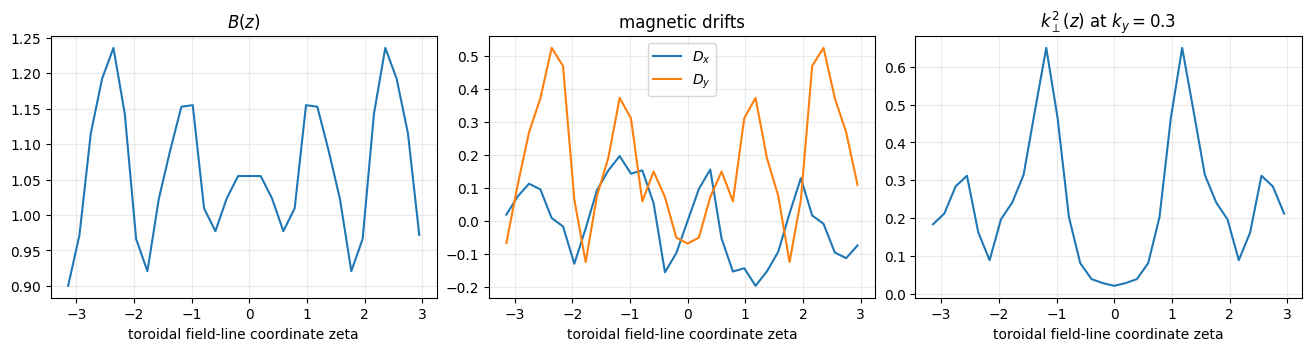

In [3]:
fourier = build_fourier_grid(FourierGridSpec(n_kx=1, n_ky=1, kx_max=0.0, ky_values=(0.3,)))
kp2 = np.asarray(k_perp_squared(geometry, fourier)).squeeze()
z = np.asarray(parallel.z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
axes[0].plot(z, np.asarray(geometry.B))
axes[0].set_title(r"$B(z)$")
axes[1].plot(z, np.asarray(geometry.D_x), label=r"$D_x$")
axes[1].plot(z, np.asarray(geometry.D_y), label=r"$D_y$")
axes[1].legend()
axes[1].set_title("magnetic drifts")
axes[2].plot(z, kp2)
axes[2].set_title(r"$k_\perp^2(z)$ at $k_y=0.3$")
for ax in axes:
    ax.set_xlabel("toroidal field-line coordinate zeta")
    ax.grid(alpha=0.25)
plt.show()

## Reduced gyrokinetic evaluation

The local solver never edits VMEC data. It consumes the normalized field-line coefficients, builds a distribution state on `(v_parallel, mu, z, kx, ky)`, advances the linear residual, obtains the electrostatic field response, and reports mode diagnostics. The objective contract can weight selected/worst/softmax growth, frequency mismatch, mode-shape mismatch, and a quasilinear proxy. Two time steps and one mode below are only a fast integration trace.

In [4]:
velocity = build_velocity_grid(VelocityGridSpec(n_vpar=2, n_mu=2, vpar_max=1.5, mu_max=1.0))
connectivity = build_mode_connectivity(fourier)
shape = (velocity.vpar.size, velocity.mu.size, parallel.z.size, 1, 1)
index = jnp.arange(np.prod(shape), dtype=jnp.float64).reshape(shape)
initial_state = 1e-2 * (jnp.cos(index / 7.0) + 1j * jnp.sin(index / 11.0))
spec = DesignObjectiveSpec(selected_ky=0, growth_weight=1.0)
config = SingleSurfaceOptimizationConfig(
    geometry_model="precomputed", dt=0.005, n_steps=2, selected_ky=0,
    objective_kind="selected_growth", store_history=False,
)

def gk_objective(local_geometry, temperature_gradient=2.1):
    return design_objective(
        OptimizationKnobs(density_gradient=0.8, temperature_gradient=temperature_gradient),
        velocity, parallel, fourier, initial_state, spec, connectivity=connectivity,
        config=config, geometry=local_geometry,
    )

result = gk_objective(geometry)
profile_grad = jax.grad(lambda a: gk_objective(geometry, a).scalar_objective)(jnp.array(2.1))
print(f"objective={float(result.scalar_objective): .6e}")
print(f"growth={float(result.selected_growth_rate): .6e}, frequency={float(result.selected_frequency): .6e}")
print(f"fixed-geometry d objective / d(R/L_T)={float(profile_grad): .6e}")

objective=-2.200674e-01
growth=-2.200674e-01, frequency= 1.157848e-01
fixed-geometry d objective / d(R/L_T)=-2.831499e-07


## Boundary-harmonic outer loop

For one real VMEC harmonic, copy the named input, scale `rbc[m, ntor+n]` and `zbs[m, ntor+n]`, run VMEC++, reconstruct geometry, and evaluate the GK objective. Central differences compare fresh solves at $p+h$ and $p-h$. Keep all grid sizes and solver controls fixed and call `assert_fixed_optimization_topology` before accepting a comparison.

The next cell is an executable **interface surrogate**, using cosine-$B$ amplitude and a geometric proxy so that the notebook needs no VMEC++ installation. The following cell gives the real call pattern.

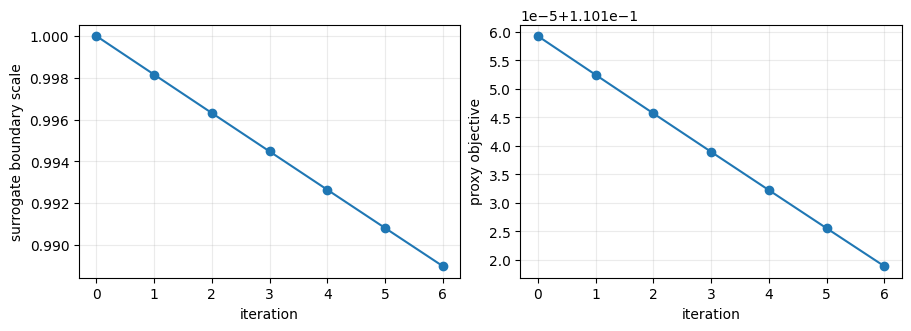

In [5]:
def surrogate_cost(boundary_scale):
    candidate = resolve_geometry(
        SyntheticGeometryProvider(magnetic_field_amplitude=0.18 * boundary_scale, iota=0.9, shear=0.2, nfp=5),
        request,
    )
    geom = internal_geometry_from_result(candidate)
    return float(jnp.mean(k_perp_squared(geom, fourier) / geom.B[:, None, None]))

scale, h, rate = 1.0, 1e-3, 0.5
history = []
for iteration in range(7):
    value = surrogate_cost(scale)
    gradient = (surrogate_cost(scale + h) - surrogate_cost(scale - h)) / (2 * h)
    history.append((iteration, scale, value, gradient))
    scale = float(np.clip(scale - rate * gradient, 0.8, 1.2))
history = np.asarray(history)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
axes[0].plot(history[:, 0], history[:, 1], "o-")
axes[0].set_ylabel("surrogate boundary scale")
axes[1].plot(history[:, 0], history[:, 2], "o-")
axes[1].set_ylabel("proxy objective")
for ax in axes:
    ax.set_xlabel("iteration")
    ax.grid(alpha=0.25)
plt.show()

central-difference sensitivity: -3.259415e-01
bounded proposed next scale: 1.003259
[{'scale': 0.995, 'rbc': 0.48847535, 'zbs': 0.6165517500000001, 'objective': -0.21840502936374406, 'growth_rate': -0.21840502936374406, 'frequency': 0.11553876205230455, 'provider': 'vmecpp'}, {'scale': 1.0, 'rbc': 0.49093, 'zbs': 0.61965, 'objective': -0.22006742039692995, 'growth_rate': -0.22006742039692995, 'frequency': 0.11578481855072048, 'provider': 'vmecpp'}, {'scale': 1.005, 'rbc': 0.4933846499999999, 'zbs': 0.62274825, 'objective': -0.22166444426652276, 'growth_rate': -0.22166444426652276, 'frequency': 0.11603039760060013, 'provider': 'vmecpp'}]
saved /Users/mohsensadr/Codes/GitHub/fusion/optimal-fusion/figures/vmecpp_initial_live_design_scan.png


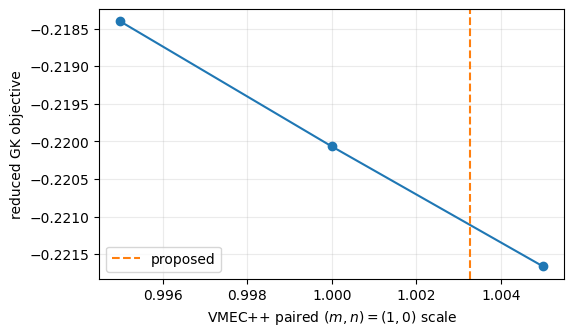

In [6]:
reference_topology = build_optimization_topology_contract(
    velocity, parallel, fourier, connectivity=connectivity,
    geometry_metadata=geometry_result.metadata,
)

def evaluate_live_vmecpp_design(boundary_scale, m=1, n=0):
    """Scale paired VMEC harmonics, run VMEC++, and evaluate reduced GK."""
    import copy

    import vmecpp

    vmec_input = copy.deepcopy(vmecpp.named_configuration("w7x-standard"))
    coefficient_index = int(vmec_input.ntor) + n
    reference_rbc = float(vmec_input.rbc[m, coefficient_index])
    reference_zbs = float(vmec_input.zbs[m, coefficient_index])
    vmec_input.rbc[m, coefficient_index] = boundary_scale * reference_rbc
    vmec_input.zbs[m, coefficient_index] = boundary_scale * reference_zbs
    candidate_result = resolve_geometry(
        VmecppGeometryProvider(
            vmec_input=vmec_input, runner=vmecpp.run, max_threads=1,
            revision="record-your-revision",
        ),
        request,
    )
    candidate_topology = build_optimization_topology_contract(
        velocity, candidate_result.parallel_grid, fourier, connectivity=connectivity,
        geometry_metadata=candidate_result.metadata,
    )
    assert_fixed_optimization_topology(reference_topology, candidate_topology)
    objective = gk_objective(internal_geometry_from_result(candidate_result))
    return {
        "scale": float(boundary_scale),
        "rbc": float(vmec_input.rbc[m, coefficient_index]),
        "zbs": float(vmec_input.zbs[m, coefficient_index]),
        "objective": float(objective.scalar_objective),
        "growth_rate": float(objective.selected_growth_rate),
        "frequency": float(objective.selected_frequency),
        "provider": candidate_result.metadata.provenance.provider,
    }

if GEOMETRY_SOURCE == "provider":
    design_scales = np.array([0.995, 1.0, 1.005])
    live_design = [evaluate_live_vmecpp_design(scale) for scale in design_scales]
    objectives = np.array([row["objective"] for row in live_design])
    sensitivity = (objectives[2] - objectives[0]) / (design_scales[2] - design_scales[0])
    proposed_scale = float(np.clip(1.0 - 0.01 * sensitivity, 0.98, 1.02))
    print(f"central-difference sensitivity: {sensitivity:.6e}")
    print(f"bounded proposed next scale: {proposed_scale:.6f}")
    print(live_design)
    plt.figure(figsize=(6, 3.5))
    plt.plot(design_scales, objectives, "o-")
    plt.axvline(proposed_scale, color="tab:orange", linestyle="--", label="proposed")
    plt.xlabel(r"VMEC++ paired $(m,n)=(1,0)$ scale")
    plt.ylabel("reduced GK objective")
    plt.grid(alpha=0.25)
    plt.legend()
    figure_path = ROOT / "figures/vmecpp_initial_live_design_scan.png"
    plt.savefig(figure_path, dpi=160, bbox_inches="tight")
    print(f"saved {figure_path}")
    plt.show()
else:
    print("Select GEOMETRY_SOURCE='provider' to run the live VMEC++ design scan.")

### From demonstration to useful optimization

Start with a handful of stellarator-symmetric harmonics and strict bounds. Evaluate multiple `(rho, alpha, ky)` samples, use mean-plus-worst-case aggregation, retain VMEC force-balance/convergence metrics, and cache each evaluation with provenance. Perform finite-difference step audits and higher-resolution rechecks. The standalone real loop can be run from the repository root with `uv run --extra dev --extra reference python examples/vmecpp_w7x_design_loop.py --iterations 2`.

![Initial live VMEC++ design sensitivity](../figures/vmecpp_initial_live_design_scan.png)